In [1]:
import happi

In [14]:
# Open the simulation results
S = happi.Open(".")

Loaded simulation 'plasma_mirror'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics


In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Extract all available timesteps recorded in the diagnostics
timesteps = S.Field(0, "Env_E_abs").getTimesteps()
print(f"=== Simulation Analytics ===")
print(f"Total recorded frames: {len(timesteps)}")
print(f"Timestep range: {timesteps[0]} to {timesteps[-1]}\n")

# Let's sample key snapshots: Start (Initial), Middle (Entering Plasma), and End 
sample_indices = [0, len(timesteps) // 2, -1]

for idx in sample_indices:
    t = timesteps[idx]
    print(f"--- Timestep {t} (Frame Index {idx}) ---")
    
    # 1. Inspect the Laser Envelope Amplitude (Env_E_abs)
    Env_data = np.array(S.Field(0, "Env_E_abs", timesteps=t).getData()[0])
    max_Env = np.max(Env_data)
    
    # 2. Inspect the Longitudinal Wakefield (Ex) generated behind the pulse
    Ex_data = np.array(S.Field(0, "Ex", timesteps=t).getData()[0])
    mean_Ex = np.mean(Ex_data)
    std_Ex = np.std(Ex_data)
    max_Ex = np.max(np.abs(Ex_data))
    
    # 3. Inspect the Electron Density (Rho_electron)
    rho_data = np.array(S.Field(0, "Rho_electron", timesteps=t).getData()[0])
    # Electrons have negative charge density; let's track the maximum displacement/compression
    peak_compression = np.min(rho_data)
    peak_cavitation = np.max(rho_data) # Cavitation approaches 0 (vacuum) from -0.01
    
    print(f"  [Laser Envelope] Max Amplitude      : {max_Env:.5f}")
    print(f"  [Wakefield Ex ] Max Acceleration Field: {max_Ex:.5f} | StdDev: {std_Ex:.5f}")
    print(f"  [Plasma Density] Peak Compression    : {peak_compression:.5f} | Peak Cavitation: {peak_cavitation:.5f}")
    print("-" * 60)

=== Simulation Analytics ===
Total recorded frames: 151
Timestep range: 0.0 to 1885.0

--- Timestep 0.0 (Frame Index 0) ---
  [Laser Envelope] Max Amplitude      : 0.00000
  [Wakefield Ex ] Max Acceleration Field: 0.00000 | StdDev: 0.00000
  [Plasma Density] Peak Compression    : -0.01000 | Peak Cavitation: 0.00000
------------------------------------------------------------
--- Timestep 942.0 (Frame Index 75) ---
  [Laser Envelope] Max Amplitude      : 1.00231
  [Wakefield Ex ] Max Acceleration Field: 0.03075 | StdDev: 0.01391
  [Plasma Density] Peak Compression    : -0.01692 | Peak Cavitation: 0.00000
------------------------------------------------------------
--- Timestep 1885.0 (Frame Index -1) ---
  [Laser Envelope] Max Amplitude      : 1.00260
  [Wakefield Ex ] Max Acceleration Field: 0.04583 | StdDev: 0.01730
  [Plasma Density] Peak Compression    : -0.02745 | Peak Cavitation: 0.00000
------------------------------------------------------------


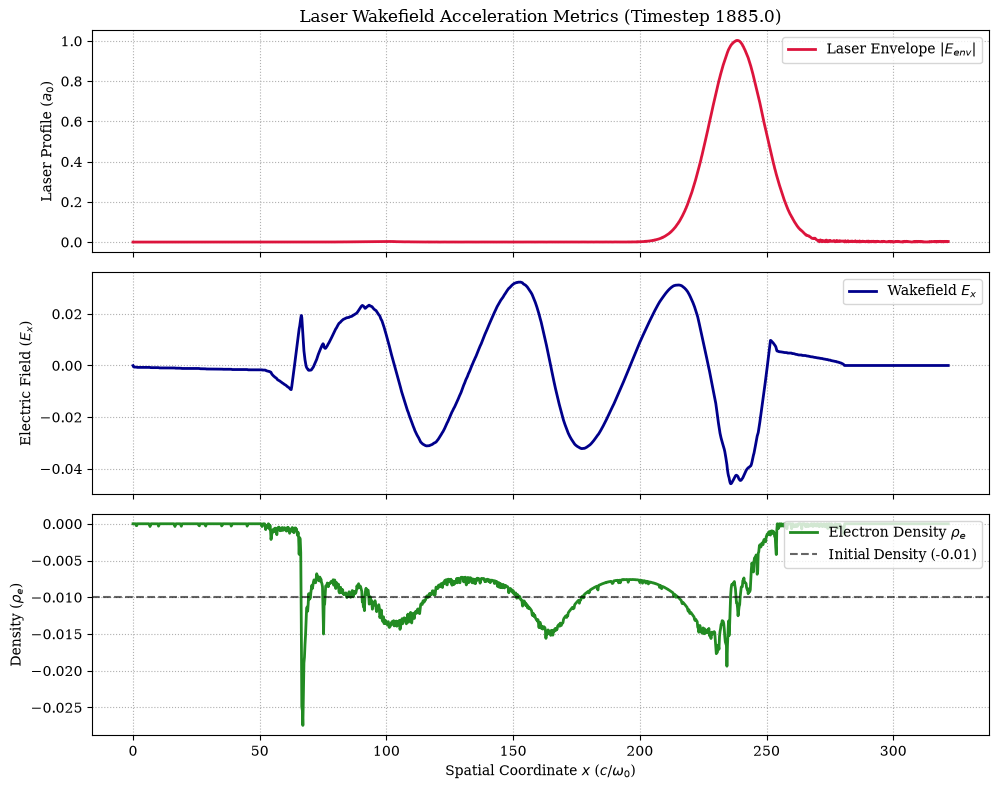

In [20]:
# Select the final timestep to view the fully developed wakefield
t_final = S.Field(0, "Env_E_abs").getTimesteps()[-1]

# Extract spatial grids and data arrays
xaxis = S.Field(0, "Env_E_abs").getAxis("x")

env_data = S.Field(0, "Env_E_abs", timesteps=t_final).getData()[0]
ex_data = S.Field(0, "Ex", timesteps=t_final).getData()[0]
rho_data = S.Field(0, "Rho_electron", timesteps=t_final).getData()[0]

# Setup a clean 3-panel physical plot layout
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Panel 1: The Laser Envelope Pulse
ax1.plot(xaxis, env_data, color='crimson', lw=2, label=r'Laser Envelope $|E_{env}|$')
ax1.set_ylabel('Laser Profile ($a_0$)')
ax1.grid(True, linestyle=':')
ax1.legend(loc='upper right')
ax1.set_title(f'Laser Wakefield Acceleration Metrics (Timestep {t_final})', fontsize=12)

# Panel 2: The Electrostatic Wakefield (Ex)
ax2.plot(xaxis, ex_data, color='darkblue', lw=2, label=r'Wakefield $E_x$')
ax2.set_ylabel('Electric Field ($E_x$)')
ax2.grid(True, linestyle=':')
ax2.legend(loc='upper right')

# Panel 3: Plasma Electron Density Perturbations
# Fixed: Added 'r' prefix for raw string to safely pass \rho
ax3.plot(xaxis, rho_data, color='forestgreen', lw=2, label=r'Electron Density $\rho_e$')
ax3.axhline(-0.01, color='black', linestyle='--', alpha=0.6, label='Initial Density (-0.01)')
ax3.set_ylabel(r'Density ($\rho_e$)')

# Fixed: Added 'r' prefix for raw string to safely pass \omega
ax3.set_xlabel(r'Spatial Coordinate $x$ ($c/\omega_0$)')
ax3.grid(True, linestyle=':')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig("lwfa_envelope_analysis.png", dpi=300)
plt.show()